In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
df=pd.read_csv('homeprices.csv')
df.head()

,area,bedrooms,age,price
0,2600,3,20,550000
1,3000,4,15,565000
2,3200,3,18,610000
3,3600,3,30,595000
4,4000,5,8,760000


In [6]:
from sklearn import preprocessing
sx=preprocessing.MinMaxScaler()
sy=preprocessing.MinMaxScaler()

scaled_X=sx.fit_transform(df.drop('price', axis='columns'))
scaled_Y=sy.fit_transform(df['price'].values.reshape(df.shape[0],1))

scaled_X

array([[0.        , 0.        , 0.54545455],
       [0.26666667, 0.33333333, 0.31818182],
       [0.4       , 0.        , 0.45454545],
       [0.66666667, 0.        , 1.        ],
       [0.93333333, 0.66666667, 0.        ],
       [1.        , 1.        , 0.        ]])

In [7]:
scaled_Y

array([[0.        ],
       [0.05769231],
       [0.23076923],
       [0.17307692],
       [0.80769231],
       [1.        ]])

In [8]:
scaled_Y.reshape(scaled_Y.shape[0],)

array([0.        , 0.05769231, 0.23076923, 0.17307692, 0.80769231,
       1.        ])

In [9]:
scaled_X.shape[1]

3

In [10]:
scaled_Y.shape

(6, 1)

In [ ]:
def batch_gradient_descent(X, y_true, epochs, learning_rate = 0.01):

    number_of_features = X.shape[1]
    w = np.ones(shape=(number_of_features))
    b = 0
    total_samples = X.shape[0] # number of rows in X
    cost_list = []
    epoch_list = []
    for i in range(epochs):        
        y_predicted = np.dot(w, X.T) + b
        w_grad = -(2/total_samples)*(X.T.dot(y_true-y_predicted))
        b_grad = -(2/total_samples)*np.sum(y_true-y_predicted)
        
        w = w - learning_rate * w_grad
        b = b - learning_rate * b_grad
        
        cost = np.mean(np.square(y_true-y_predicted)) # MSE (Mean Squared Error)
        
        if i%10==0:
            cost_list.append(cost)
            epoch_list.append(i)
        
    return w, b, cost, cost_list, epoch_list

w, b, cost, cost_list, epoch_list = batch_gradient_descent(scaled_X,scaled_Y.reshape(scaled_Y.shape[0],),500)
w, b, cost

(array([0.58463554, 0.889126  , 0.47655921]),
 np.float64(-0.4336741733568186),
 np.float64(0.028058695087929738))

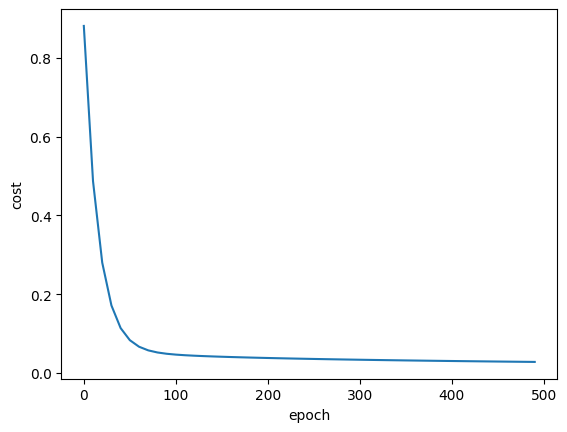

In [12]:

plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list,cost_list)

In [13]:
import random
random.randint(0,6)

6

In [ ]:
def stochastic_gradient_descent(X, y_true, epochs, learning_rate = 0.01):
 
    number_of_features = X.shape[1]
    # numpy array with 1 row and columns equal to number of features. In 
    # our case number_of_features = 3 (area, bedroom and age)
    w = np.ones(shape=(number_of_features)) 
    b = 0
    total_samples = X.shape[0]
    
    cost_list = []
    epoch_list = []
    
    for i in range(epochs):    
        random_index = random.randint(0,total_samples-1) # random index from total samples
        sample_x = X[random_index]
        sample_y = y_true[random_index]
        
        y_predicted = np.dot(w, sample_x.T) + b
    
        w_grad = -(2/total_samples)*(sample_x.T.dot(sample_y-y_predicted))
        b_grad = -(2/total_samples)*(sample_y-y_predicted)
        
        w = w - learning_rate * w_grad
        b = b - learning_rate * b_grad
        
        cost = np.square(sample_y-y_predicted)
        
        if i%100==0: # at every 100th iteration record the cost and epoch value
            cost_list.append(cost)
            epoch_list.append(i)
        
    return w, b, cost, cost_list, epoch_list

w_sgd, b_sgd, cost_sgd, cost_list_sgd, epoch_list_sgd = stochastic_gradient_descent(scaled_X,scaled_Y.reshape(scaled_Y.shape[0],),10000)
w_sgd, b_sgd, cost_sgd

(array([0.46202236, 0.79109064, 0.22144273]),
 np.float64(-0.22708873256207668),
 np.float64(0.029992053407469882))

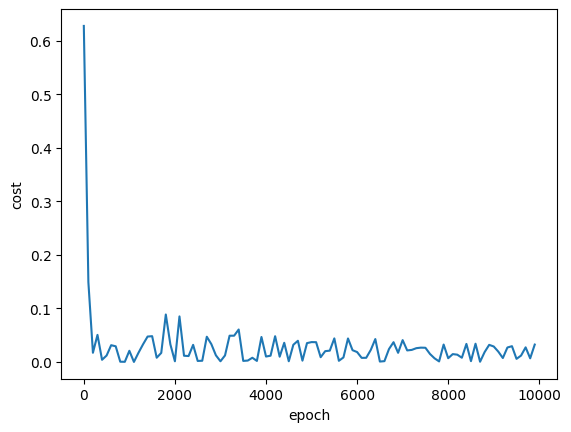

In [ ]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list_sgd,cost_list_sgd)

In [44]:
def minibatch_gradient_descent(X,y_true,epochs,learning_rate=0.01,batch_size=5):
    number_of_feature=X.shape[1]
    w=np.ones(shape=(number_of_feature))
    b=0
    total_samples=X.shape[0]

    cost_list=[]
    epoch_list=[]

    for i in range(epochs):
        random_indices = np.random.randint(0, total_samples, batch_size)
        X_batch = X[random_indices]
        y_batch = y_true[random_indices]

        y_predicted = np.dot(w, X_batch.T) + b

        w_grad = -(2/batch_size)*(X_batch.T.dot(y_batch - y_predicted))
        b_grad = -(2/batch_size)*np.sum(y_batch - y_predicted)

        w = w - learning_rate * w_grad
        b = b - learning_rate * b_grad

        cost=np.square(y_batch-y_predicted)

        if i%100==0:
            cost_list.append(cost)
            epoch_list.append(i)
    
    return w, b, cost, cost_list, epoch_list

w_mgd, b_mgd, cost_mgd, cost_list_mgd, epoch_list_mgd= minibatch_gradient_descent(scaled_X,scaled_Y.reshape(scaled_Y.shape[0],),1000)
w_mgd, b_mgd, cost_mgd

(array([0.48777006, 0.8596803 , 0.33530899]),
 np.float64(-0.3076459829086451),
 array([0.03529767, 0.00184478, 0.03391528, 0.03391528, 0.03391528]))

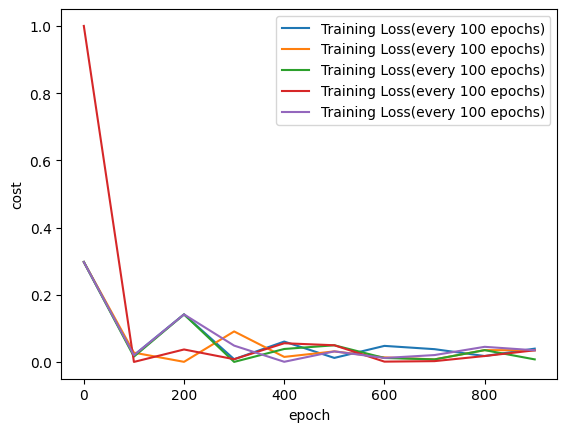

In [47]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list_mgd, cost_list_mgd, label="Training Loss(every 100 epochs)")
plt.legend()

__Gradient Descent, Stochastic gradient descent and Mini gradient descent__